# World Bank API Analysis

Este notebook descarga datos del Banco Mundial para 5 países y 2 indicadores, limpia los resultados y genera visualizaciones.

In [28]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


In [29]:
BASE_URL = 'https://api.worldbank.org/v2'
countries = ['ARG', 'BRA', 'CHL', 'COL', 'MEX']
indicators = {
    'NY.GDP.PCAP.CD': 'gdp_per_capita',
    'SP.DYN.LE00.IN': 'life_expectancy',
}
params = {
    'format': 'json',
    'per_page': 100,
}

def fetch_indicator_data(country_codes, indicator_id, start_year=2010, end_year=2024):
    endpoint = f"{BASE_URL}/country/{';'.join(country_codes)}/indicator/{indicator_id}"
    rows = []
    page = 1

    while True:
        params['page'] = page
        params['date'] = f'{start_year}:{end_year}'

        response = requests.get(endpoint, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()

        if not isinstance(payload, list) or len(payload) < 2:
            break

        metadata, data = payload[0], payload[1]
        rows.extend(data or [])

        if page >= int(metadata.get('pages', 1)):
            break
        page += 1

    return rows


In [30]:
raw_gdp = fetch_indicator_data(countries, 'NY.GDP.PCAP.CD')
raw_life = fetch_indicator_data(countries, 'SP.DYN.LE00.IN')

df_gdp = pd.json_normalize(raw_gdp)
df_life = pd.json_normalize(raw_life)

common_cols = ['country.value', 'date', 'value']
df1 = df_gdp[common_cols].rename(columns={'country.value': 'country', 'date': 'year'}).copy()
df2 = df_life[common_cols].rename(columns={'country.value': 'country', 'date': 'year'}).copy()

for df in (df1, df2):
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df.dropna(subset=['value'], inplace=True)
    df.sort_values(['country', 'year'], inplace=True)
    df.reset_index(drop=True, inplace=True)

print('GDP per capita rows:', len(df1))
print('Life expectancy rows:', len(df2))


GDP per capita rows: 75
Life expectancy rows: 75


## Revisión rápida de los datos

A continuación se muestran las primeras filas de cada tabla y los tipos de datos después de la limpieza mínima requerida.

In [31]:
display(df1.head())
display(df2.head())
print('df1 dtypes:', df1.dtypes)
print('df2 dtypes:', df2.dtypes)


,country,year,value
0,Argentina,2010,10260.131311
1,Argentina,2011,12704.283182
2,Argentina,2012,12949.717487
3,Argentina,2013,12963.675773
4,Argentina,2014,12233.144412


,country,year,value
0,Argentina,2010,75.680
1,Argentina,2011,76.100
2,Argentina,2012,75.802
3,Argentina,2013,75.829
4,Argentina,2014,76.268


df1 dtypes: country        str
year         Int64
value      float64
dtype: object
df2 dtypes: country        str
year         Int64
value      float64
dtype: object


## Visualización 1: evolución de indicadores por país

Estas gráficas muestran la evolución del GDP per cápita y la esperanza de vida para los países seleccionados entre 2010 y 2024.

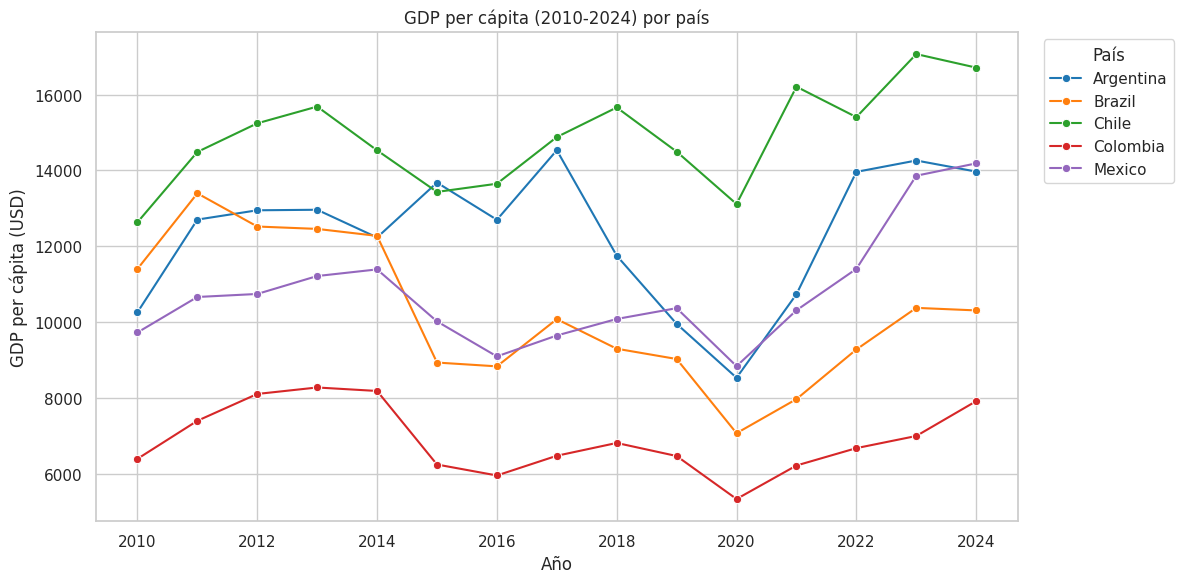

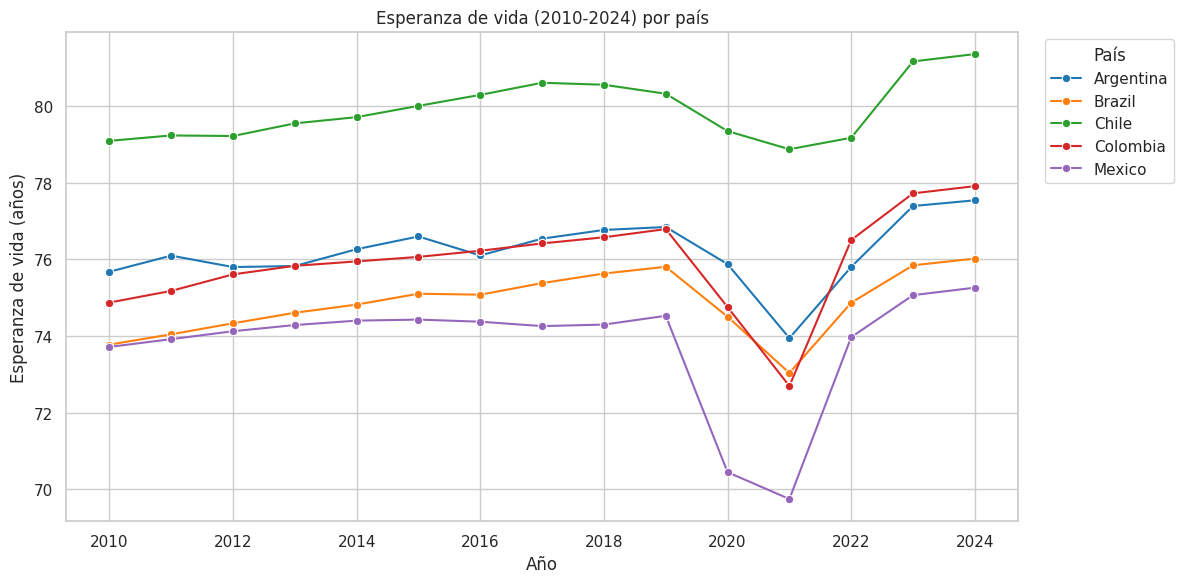

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df1, x='year', y='value', hue='country', marker='o', palette='tab10')
plt.title('GDP per cápita (2010-2024) por país')
plt.xlabel('Año')
plt.ylabel('GDP per cápita (USD)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='year', y='value', hue='country', marker='o', palette='tab10')
plt.title('Esperanza de vida (2010-2024) por país')
plt.xlabel('Año')
plt.ylabel('Esperanza de vida (años)')
plt.legend(title='País', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Visualización 2: relación entre indicadores para un año reciente

El siguiente gráfico compara el GDP per cápita y la esperanza de vida para el año más reciente disponible. De esta forma es posible observar si los países con mayor ingreso tienen también mayor esperanza de vida.

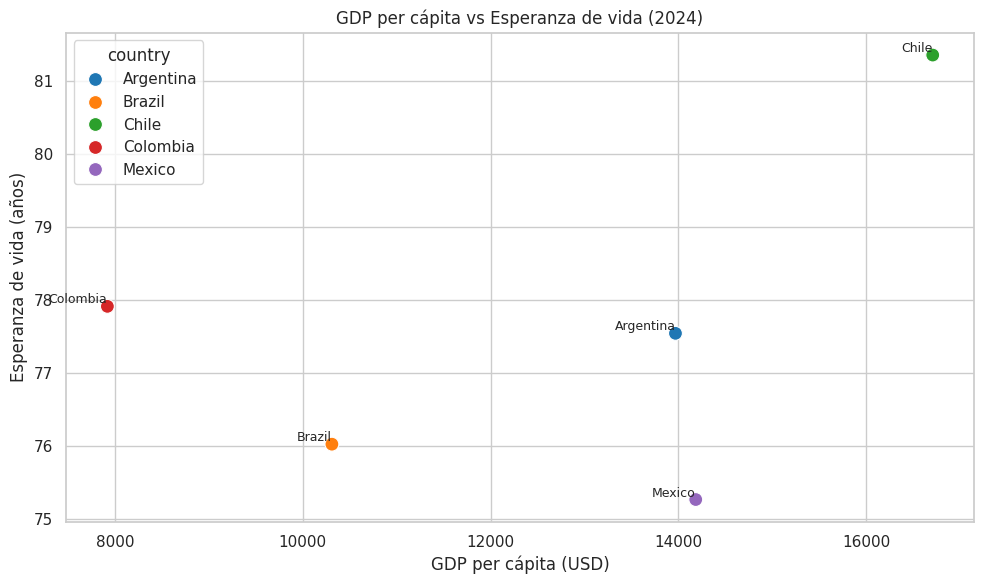

Año usado: 2024
     country  gdp_per_capita  life_expectancy
0  Argentina    13969.783660           77.543
1     Brazil    10310.548878           76.023
2      Chile    16709.889397           81.359
3   Colombia     7919.208868           77.913
4     Mexico    14185.781225           75.264


In [33]:
recent_year = int(df1['year'].max())

gdp_recent = df1[df1['year'] == recent_year].rename(columns={'value': 'gdp_per_capita'})
life_recent = df2[df2['year'] == recent_year].rename(columns={'value': 'life_expectancy'})

merged_recent = pd.merge(
    gdp_recent[['country', 'gdp_per_capita']],
    life_recent[['country', 'life_expectancy']],
    on='country',
    how='inner'
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_recent, x='gdp_per_capita', y='life_expectancy', hue='country', s=100, palette='tab10')
for _, row in merged_recent.iterrows():
    plt.text(row['gdp_per_capita'], row['life_expectancy'], row['country'], fontsize=9, ha='right', va='bottom')

plt.title(f'GDP per cápita vs Esperanza de vida ({recent_year})')
plt.xlabel('GDP per cápita (USD)')
plt.ylabel('Esperanza de vida (años)')
plt.tight_layout()
plt.show()

print('Año usado:', recent_year)
print(merged_recent)


## Persistencia en SQLite con SQLAlchemy

A continuación guardamos cada indicador en una tabla separada dentro de la base de datos `world_bank_analysis.db`, y leemos una muestra para validar la carga.

In [34]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///world_bank_analysis.db')

raw_connection = engine.raw_connection()
dbapi_connection = raw_connection.connection

df1.to_sql('indicator_gdp_per_capita', con=dbapi_connection, if_exists='replace', index=False)
df2.to_sql('indicator_life_expectancy', con=dbapi_connection, if_exists='replace', index=False)

dbapi_connection.commit()
raw_connection.close()

print('Tablas guardadas en world_bank_analysis.db')

raw_connection = engine.raw_connection()
dbapi_connection = raw_connection.connection
sample_gdp = pd.read_sql('SELECT * FROM indicator_gdp_per_capita LIMIT 5', con=dbapi_connection)
sample_life = pd.read_sql('SELECT * FROM indicator_life_expectancy LIMIT 5', con=dbapi_connection)
raw_connection.close()

print('Sample GDP per capita:')
print(sample_gdp)
print('\nSample life expectancy:')
print(sample_life)

Tablas guardadas en world_bank_analysis.db
Sample GDP per capita:
     country  year         value
0  Argentina  2010  10260.131311
1  Argentina  2011  12704.283182
2  Argentina  2012  12949.717487
3  Argentina  2013  12963.675773
4  Argentina  2014  12233.144412

Sample life expectancy:
     country  year   value
0  Argentina  2010  75.680
1  Argentina  2011  76.100
2  Argentina  2012  75.802
3  Argentina  2013  75.829
4  Argentina  2014  76.268
